# Get on board with scRNA-seq data analysis using Scanpy
## Goals
- Learn more about the AnnData structure (.X, .obs, .var)
- Run a standard Scanpy workflow using real scRNA-seq data
- Visualize scRNA-seq data with UMAPs

### If you have already run tutorial-1, you may skip the next cell, although running it again is completely harmless. If not, make sure to run the following cell.

In [4]:
# install scanpy
%pip install scanpy
# clone the repository so that we have all the data and notebooks ready to go
!git clone https://github.com/tuonglab/FIMSA-training-workshop-1.git

fatal: destination path 'FIMSA-training-workshop-1' already exists and is not an empty directory.


In [5]:
import scanpy as sc
import pandas as pd
import numpy as np

## Load real scRNA-seq data

Here, we provide two real scRNA-seq samples for you to explore (`PICA0208` and `PICA0209`). They are from the Paediatric Immune Cell Atlas for Immunotherapy Innovation (PICACHIU) project.

For now, let's look at `PICA0208` only.

In [6]:
adata = sc.read_h5ad("/content/FIMSA-training-workshop-1/data/tutorial_2/SeekGene_PICA0208.h5ad")
adata

AnnData object with n_obs × n_vars = 11590 × 38606
    obs: 'sample', 'platform', 'is_multiplexed'
    var: 'gene_ids', 'feature_types'

## Learn more about the AnnData structure

Remember the three key parts of an AnnData object:
- `.X` → the expression matrix (cells × genes)
- `.obs` → metadata about each cell (one row per cell)
- `.var` → metadata about each gene (one row per gene)

In [7]:
print("Number of cells:", adata.n_obs)
print("Number of genes:", adata.n_vars)
print("Matrix shape:", adata.shape)

Number of cells: 11590
Number of genes: 38606
Matrix shape: (11590, 38606)


## What does the expression matrix look like?

`.X` is a cells × genes matrix. Each value is how many times a gene was detected in a given cell (a "count").

Single-cell matrices are sparse -- most entries are 0, because any single cell only expresses a fraction of all genes. To save memory, Scanpy stores `.X` in a sparse format instead of a normal dense table.

In [8]:
# Peek at a tiny corner of the matrix (bottom-right 5 cells × 5 genes)
# .toarray() converts the sparse block into a normal array so we can read it
print(adata.X[-5:, -5:].toarray())

# How "empty" is the matrix? (fraction of zeros)
n_total = adata.n_obs * adata.n_vars
n_zeros = n_total - adata.X.nnz   # nnz = number of non-zero entries
print(f"\nFraction of zeros: {n_zeros / n_total:.2%}")

[[0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Fraction of zeros: 91.44%


## Quality control (QC)

Not every "cell" in the raw data is a good cell. Some droplets contain:
- dying cells → high % of mitochondrial gene expression
- empty droplets → very few genes detected
- doublets (two cells stuck together) → unusually many genes

QC means measuring a few simple per-cell numbers so we can spot and remove low-quality cells.

We first flag mitochondrial genes -- in humans their names start with `MT-`.

In [9]:
# Flag mitochondrial genes (gene names starting with "MT-")
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Calculate standard QC metrics.
# This adds new columns to adata.obs (per-cell) and adata.var (per-gene).
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=[50],   # also compute % counts coming from MT genes
    inplace=True
)

# Look at the new per-cell QC columns
adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].head()

,n_genes_by_counts,total_counts,pct_counts_mt
GATCCCTTACGGAACTT,437,510.0,1.764706
CCACACTTACAGGAAAT,427,511.0,0.978474
CGTTGGGCGAGACCGTC,427,514.0,1.167315
ACACCAAATGACTGATG,172,521.0,63.339733
ACAAGCTGCTTAACCCA,440,526.0,1.330799


- `n_genes_by_counts` → how many different genes were detected in the cell
- `total_counts` → total number of transcripts (UMIs) in the cell
- `pct_counts_mt` → % of counts from mitochondrial genes (high = unhealthy cell)

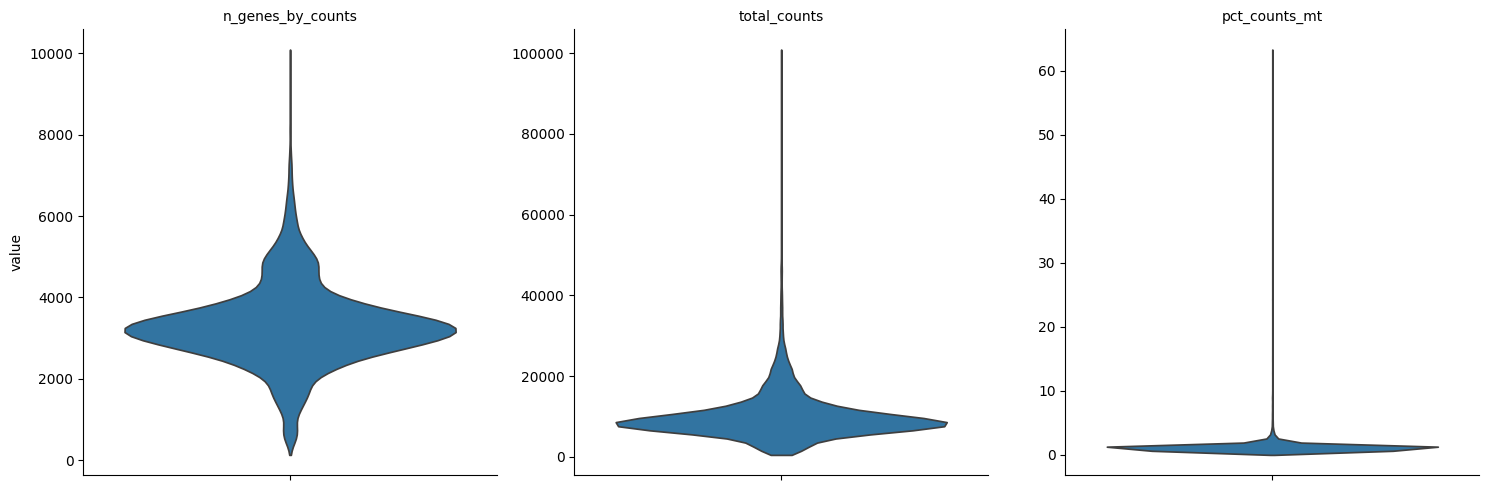

In [10]:
# Visualize the QC distributions to decide on thresholds
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    multi_panel=True,
    stripplot=False
)

### Filtering

Now we can remove the obviously low-quality cells and genes.

The exact numbers are dataset-dependent. For now, try these numbers:

- Keep cells with at least 200 genes detected
- Keep genes seen in at least 3 cells
- Drop cells with more than 5,000 genes (likely doublets)
- Drop cells with more than 10% of mitochondrial genes (dying)

In [11]:
print("Before filtering:", adata.shape)

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

adata = adata[adata.obs["n_genes_by_counts"] < 5000, :]
adata = adata[adata.obs["pct_counts_mt"] < 10, :]

print("After filtering :", adata.shape)

Before filtering: (11590, 38606)
After filtering : (10842, 27607)


## Normalization

Different cells are sequenced to different depths. One cell might have 5,000 total counts and another 20,000, purely for technical reasons. If we don't correct for this, "library size" dominates everything.

1. `Normalize` each cell to the same total count (usually 10,000)
2. `Log-transform` with `log1p` (i.e. log(x + 1)) to tame large values

Before transforming, we save a copy of the raw counts in `adata.layers`, so we can always get back to the original numbers later.

In [12]:
# Keep a copy of the raw counts
adata.layers["counts"] = adata.X.copy()

# Normalize every cell to 10,000 total counts
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform
sc.pp.log1p(adata)

# Values are now small floats instead of integer counts
print(adata.X[-5:, -5:].toarray())

/tmp/ipykernel_4028/2427299995.py:2: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


[[0.        0.        0.        0.        0.       ]
 [0.        0.        0.        0.        0.       ]
 [0.        3.9490716 0.        0.        0.       ]
 [0.        0.        0.2871082 0.        0.       ]
 [0.        0.        0.        0.        0.       ]]


## Select highly variable genes

We have thousands of genes, but most are expressed at similar levels across all cells and carry little information. Focusing on highly variable genes (HVGs) makes the analysis faster and cleaner.

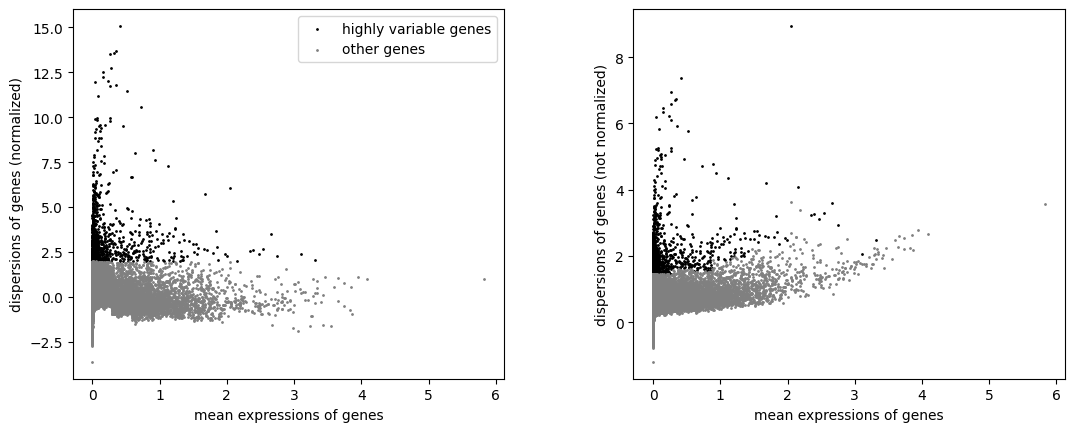

In [13]:
# Identify the top variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=1000)

# Visualize the selection
sc.pl.highly_variable_genes(adata)

In [14]:
# Keep the full set in .raw (handy for plotting any gene later),
# then restrict the working matrix to HVGs only.
adata.raw = adata
adata = adata[:, adata.var["highly_variable"]]
print("Shape after keeping HVGs:", adata.shape)

Shape after keeping HVGs: (10842, 1000)


## Scaling

Before PCA, we scale each gene so it has mean 0 and variance 1. This stops a few very highly expressed genes from dominating the principal components.

We cap (clip) extreme values at 10 to limit the influence of outliers.

In [15]:
sc.pp.scale(adata, max_value=10)
adata.X[-5:, -5:]

/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


array([[-0.02823101,  4.5417083 ,  0.68727545, -0.07694973, -0.08510754],
       [-0.02823101, -0.30033415,  0.57056135, -0.07694973, -0.08510754],
       [-0.02823101,  2.67558144, -0.32791836, -0.07694973, 10.        ],
       [-0.02823101, -0.30033415,  1.7116857 , -0.07694973, -0.08510754],
       [-0.02823101, -0.30033415,  0.30467687, -0.07694973, -0.08510754]])

## Dimensionality reduction

We can't visualize all 1,000 dimensions. The strategy is:

1. PCA → compress ~1,000 genes into a few "principal components"
2. Neighbors → build a graph connecting each cell to its most similar cells
3. UMAP → lay that graph out in 2D so we can actually plot it

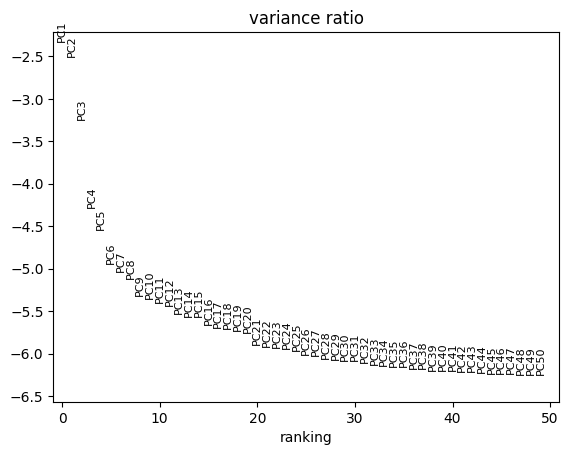

In [16]:
# PCA
sc.tl.pca(adata)

# The "elbow" plot helps you judge how many PCs carry real signal
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

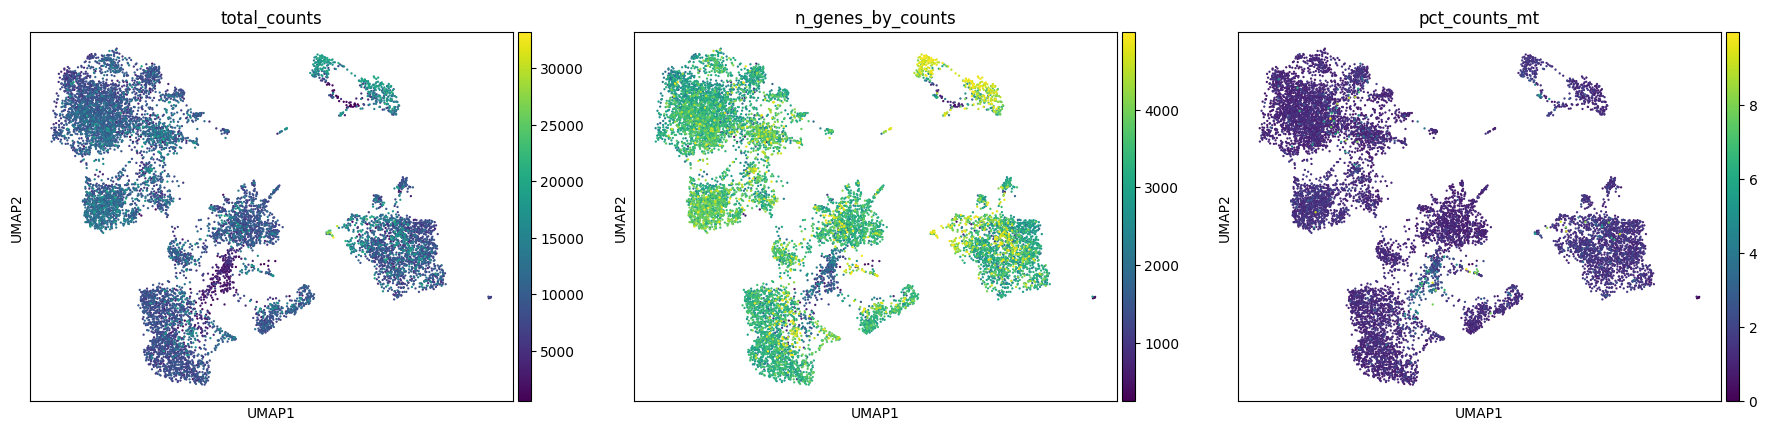

In [17]:
# Build the neighborhood graph
sc.pp.neighbors(adata)

# Compute the 2D UMAP layout
sc.tl.umap(adata)

# Colour by QC metrics to sanity-check the embedding
sc.pl.umap(adata, color=["total_counts", "n_genes_by_counts", "pct_counts_mt"])

## Clustering

UMAP gives us coordinates, but not groups. To assign cells to clusters (candidate cell types), we run the Leiden algorithm on the same neighbor graph we built above. Each cell gets a cluster label stored in `adata.obs`.

In [18]:
# install leidenalg for clustering
%pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 70.4 MB/s eta 0:00:00


In [19]:
sc.tl.leiden(adata, resolution=1.0)

# How many clusters did we get, and how big are they?
print(adata.obs["leiden"].value_counts())

/tmp/ipykernel_4028/4215228028.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1.0)


leiden
0     2066
1     1435
2     1046
3      959
4      903
5      678
6      533
7      487
8      386
9      330
10     307
11     278
12     220
13     204
14     182
15     177
16     162
17      95
18      94
19      88
20      70
21      62
22      60
23      11
24       9
Name: count, dtype: int64


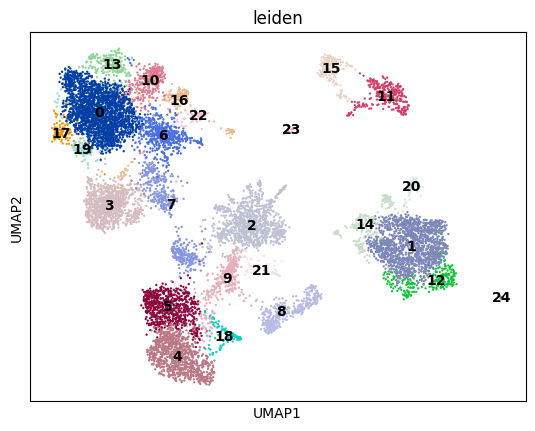

In [20]:
# Plot the clusters on the UMAP
sc.pl.umap(adata, color="leiden", legend_loc="on data")

## Finding marker genes

A cluster is only useful if we can interpret it. Marker genes are genes that are much more highly expressed in one cluster than the others, they help us find out what cell type each cluster is.

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:463: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result

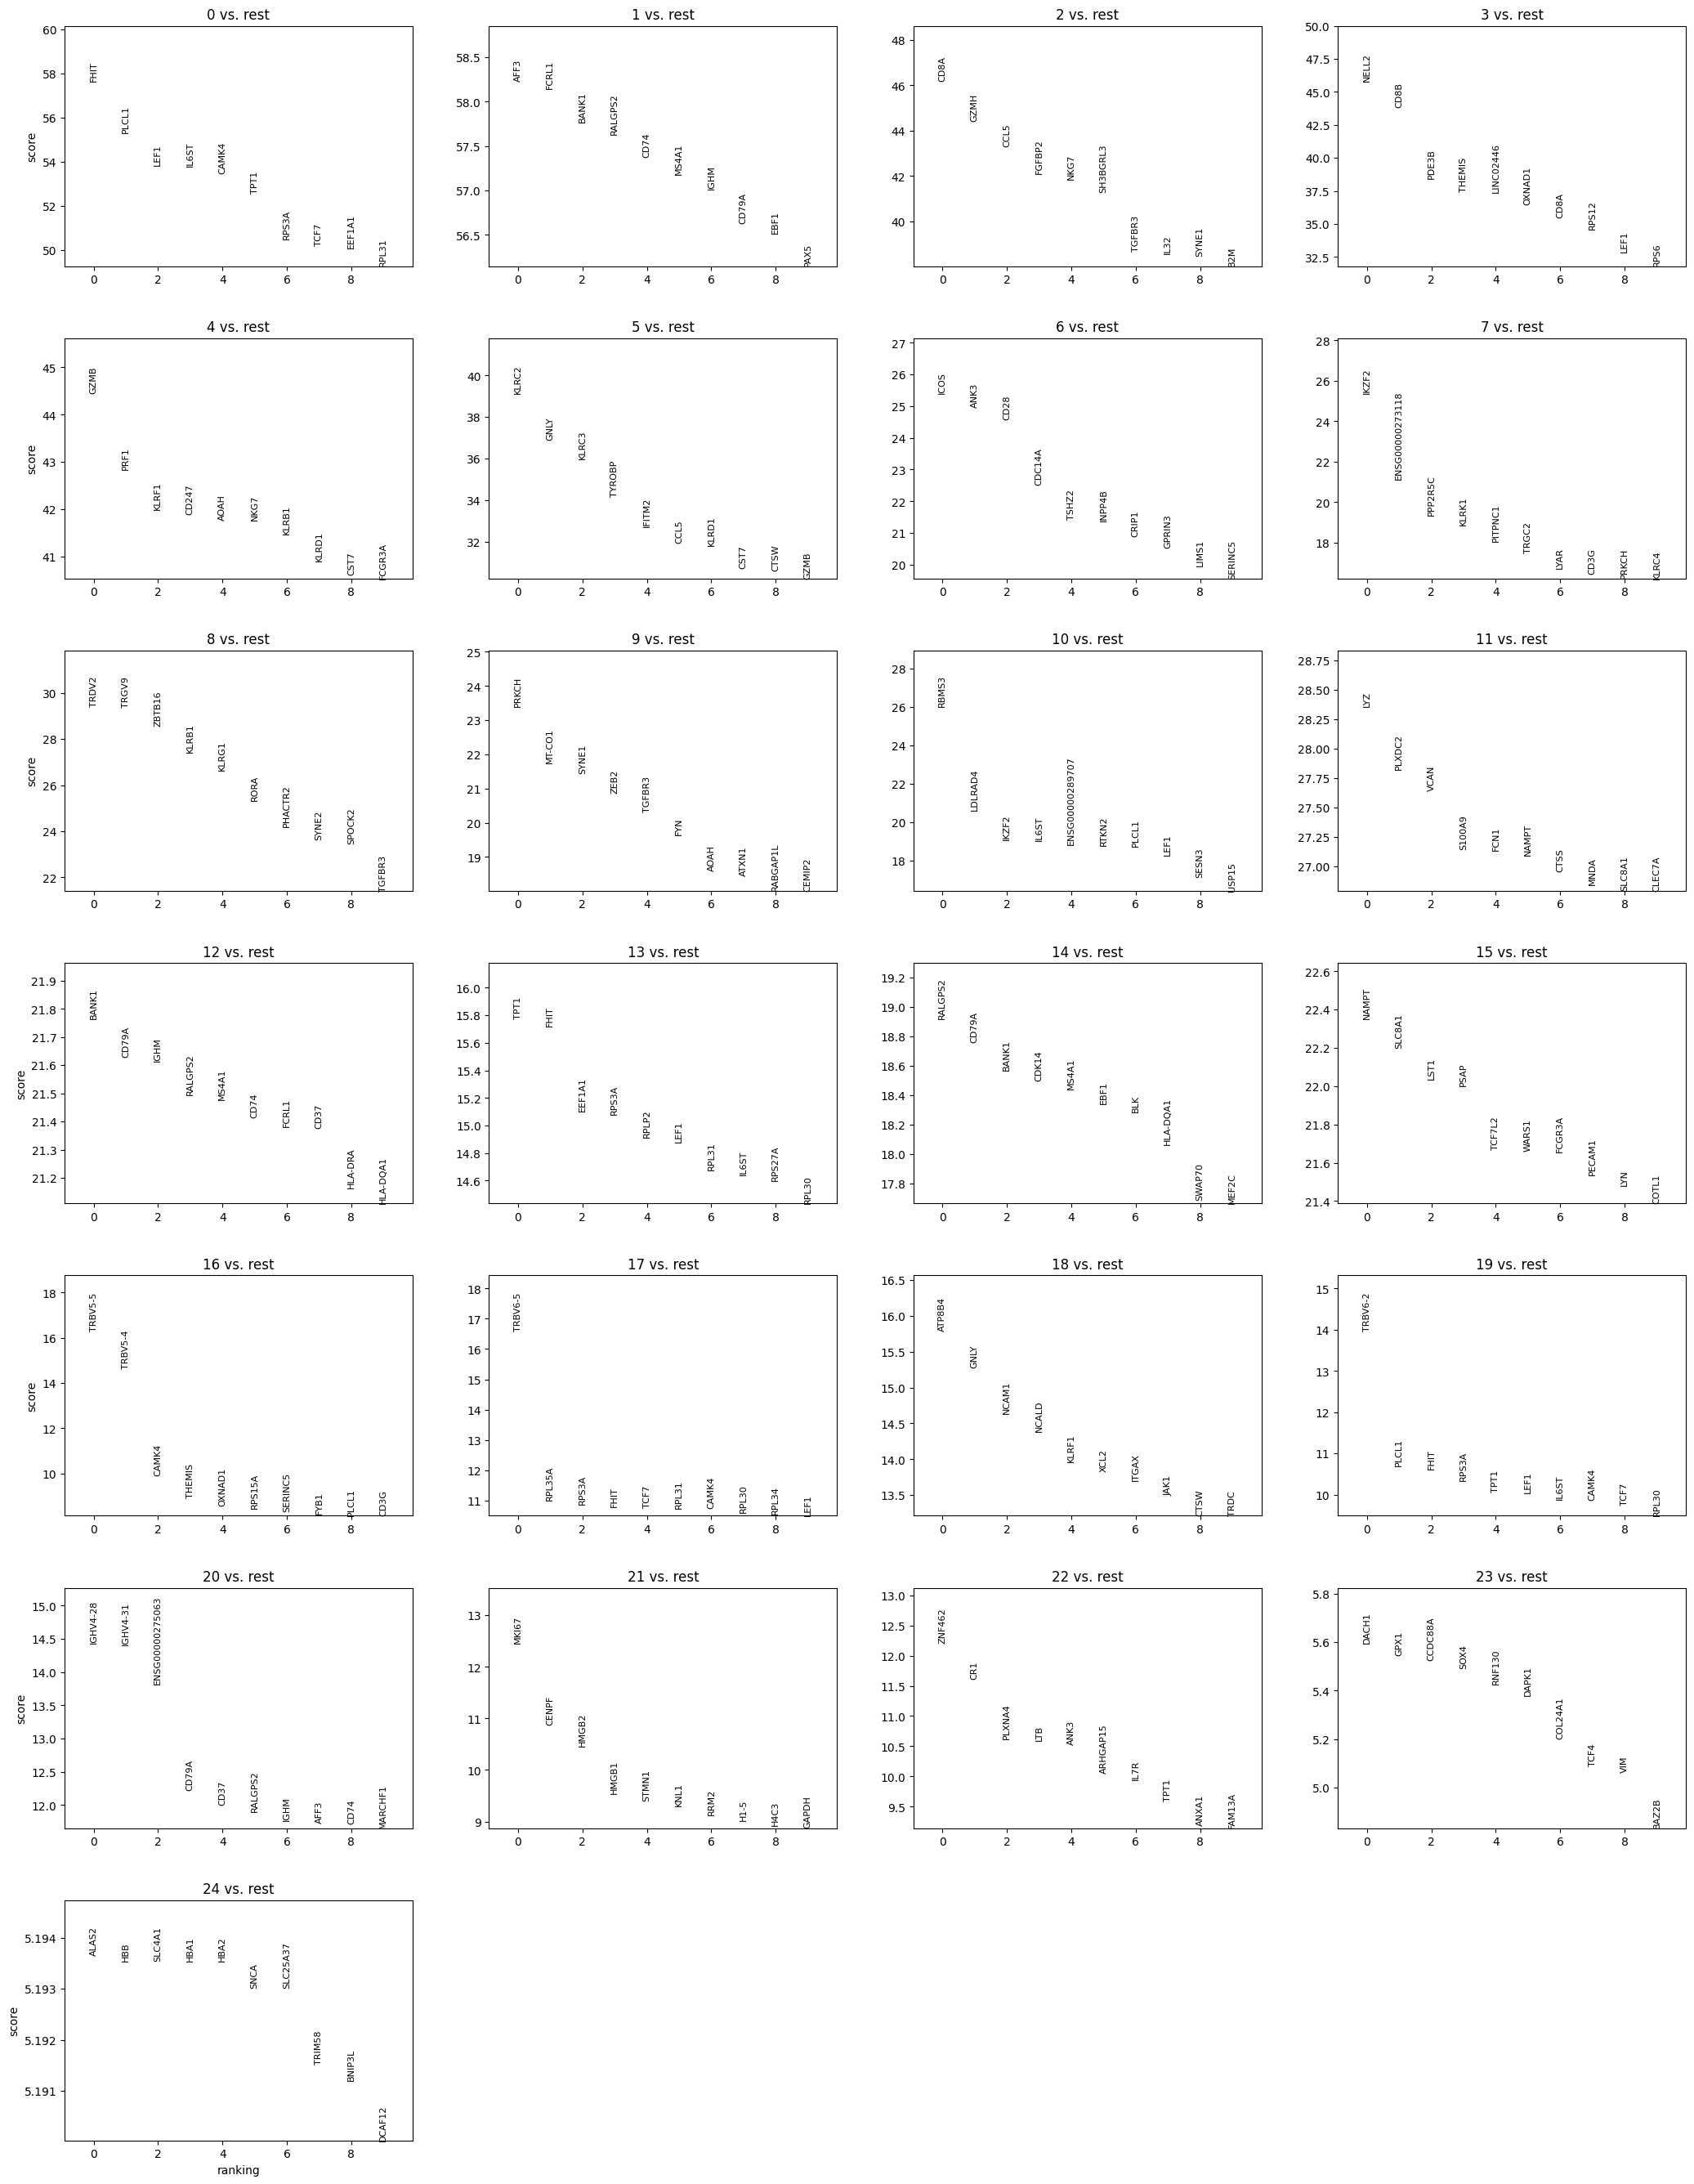

In [21]:
# Rank genes that distinguish each Leiden cluster from the rest
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")

# Plot the top markers per cluster
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

### Visualizing markers across clusters

A dotplot is a compact way to compare a handful of genes across all clusters:
- dot size = fraction of cells in the cluster expressing the gene
- dot colour = average expression level

Instead of manually pulling the top genes out, Scanpy gives us a dedicated helper that reads the results of `rank_genes_groups` directly and picks the top `n_genes` per cluster for us.

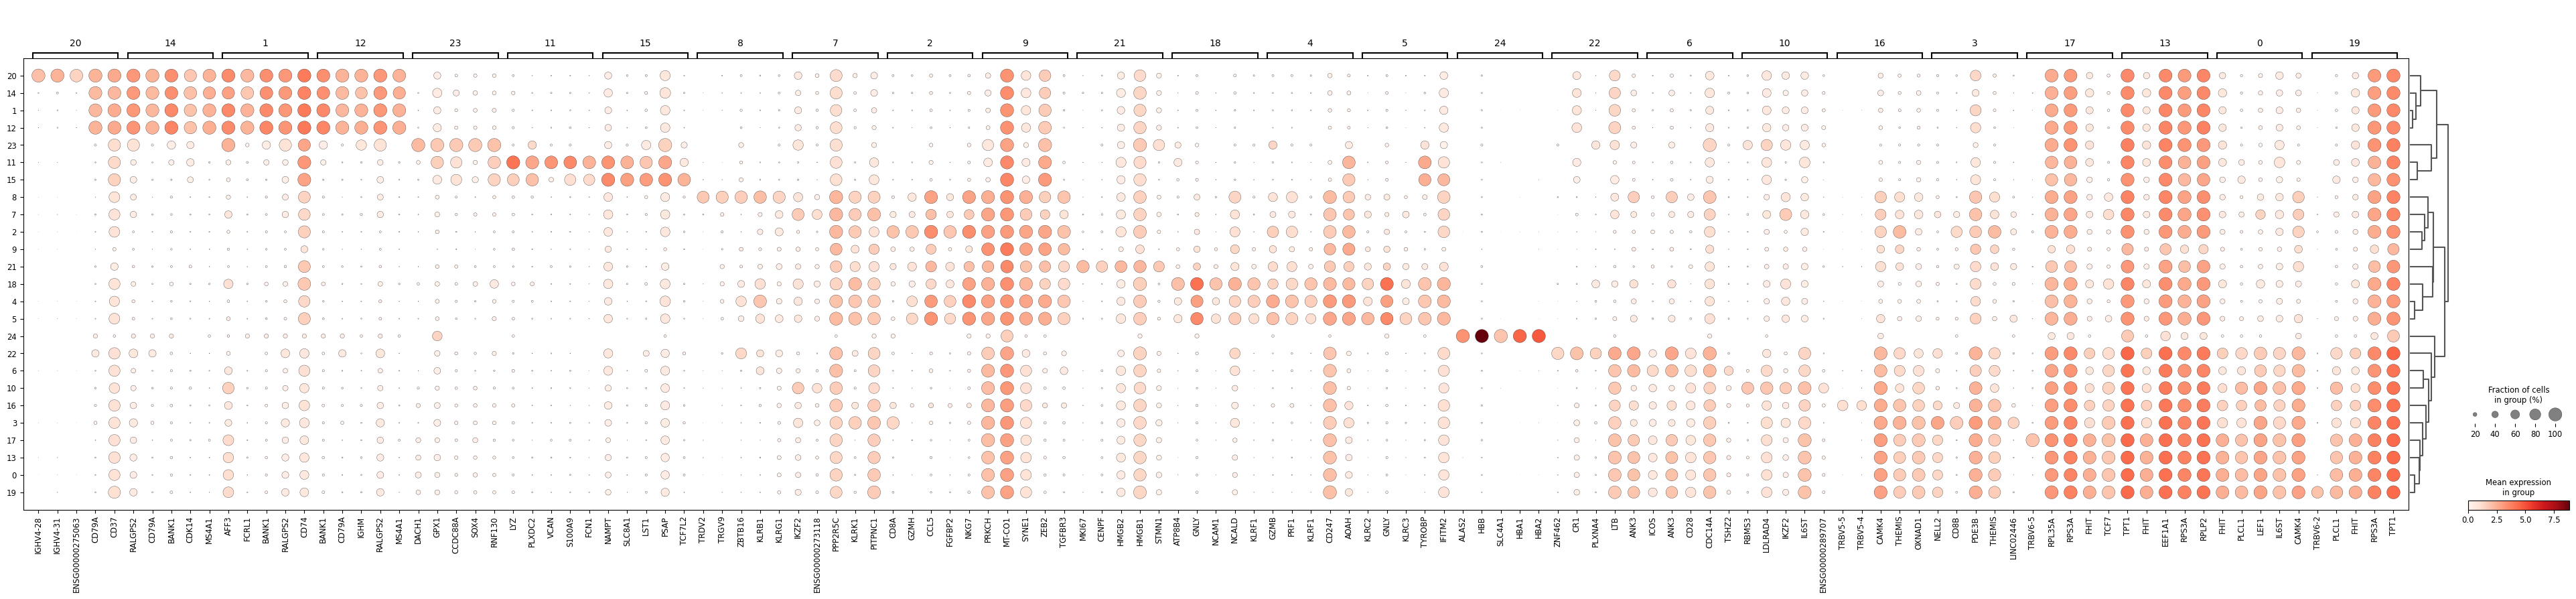

In [22]:
# Top 5 marker genes per Leiden cluster, straight from the rank_genes_groups results
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=5,
    groupby="leiden"
)

## Summary

In this tutorial we went from a raw counts matrix to an annotated UMAP:

1. QC measured per-cell quality and filtered bad cells
2. Normalize + log made cells comparable to each other
3. HVGs kept the most informative genes
4. Scale → PCA → neighbors → UMAP reduced to 2D for visualization
5. Leiden grouped cells into clusters
6. Marker genes found genes that define each cluster

Key AnnData takeaways
- `.X` changes as we process (counts → normalized → scaled)
- `.layers["counts"]` keeps the original counts safe
- `.obs` accumulates per-cell results (QC metrics, leiden labels)
- `.var` accumulates per-gene results (highly_variable, etc.)
- `.raw` stores the full gene set for plotting